2-2. 归一化
1. 背景
在前面的教程中，我们从数据集中删除了低质量的细胞，包括计数较差以及双细胞，并将数据存放在anndata文件中。由于单细胞测序技术的限制，我们在样本中获得RNA的时候，经过了分子捕获，逆转录还有测序。这些步骤会影响同一种细胞的细胞间的测序计数深度的变异性，故单细胞测序数据中的细胞间差异可能会包含了这部分测序误差，等价于计数矩阵中包含了变化很大的方差项。但在目前的统计方法中，绝大部分模型都预先假定了数据具有相同的方差结构。

伽马-泊松分布 # 修改说明: 使用 LaTeX 块/行内公式以正确渲染

从理论上和经验上建立的 UMI 数据模型是 Gamma-Poisson 分布，即

$$\mathrm{Var}[Y] = \mu + \alpha \mu^2$$

其中 $\mu$ 代表 UMI 平均值，$\alpha$ 代表细胞 UMI 的过度离散值。若 $\alpha = 0$ 时，意味着此时 UMI 的分布为泊松分布。

“归一化”的预处理步骤旨在通过将“UMI的方差”缩放到指定范围，来调整数据集中的原始UMI计数以实现模型建模。

而在真实的单细胞分析中，有不同的归一化方法以解决不同的分析问题。

但经验发现，移位对数在大部分数据中的表现良好，这在2023年4月的Nature Method上的基准测试中有提到。

本章将向读者介绍两种不同的归一化技术：
<div style = "color:yellow">
移位对数变换和皮尔逊残差的解析近似。
</div>

移位对数有利于稳定方差，以利于后续降维和差异表达基因的识别。

皮尔森近似残差可以保留生物学差异，并鉴定稀有细胞类型。

我们首先导入我们所需要的Python包，以及上一个教程分析所得到的anndata文件。

In [ ]:
import omicverse as ov
import scanpy as sc

#ov.utils.ov_plot_set() # changed 
ov.ov_plot_set() # now it's better and simpler 

/home/zhen/miniforge3/envs/scanpy_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 PyTorch not available - GPU detection skipped

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.9   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [4]:
# adata = sc.read(
#     filename="s4d8_quality_control.h5ad",
#     backup_url="https://figshare.com/ndownloader/files/40014331",
# )
adata = sc.read_10x_h5("filtered_feature_bc_matrix.h5")

reading filtered_feature_bc_matrix.h5
 (0:00:05)



我们首先检查原始计数UMI的分布，一般在后续的分析中我们会忽略这一步，但对该分布的认识有利于我们理解归一化的意义。

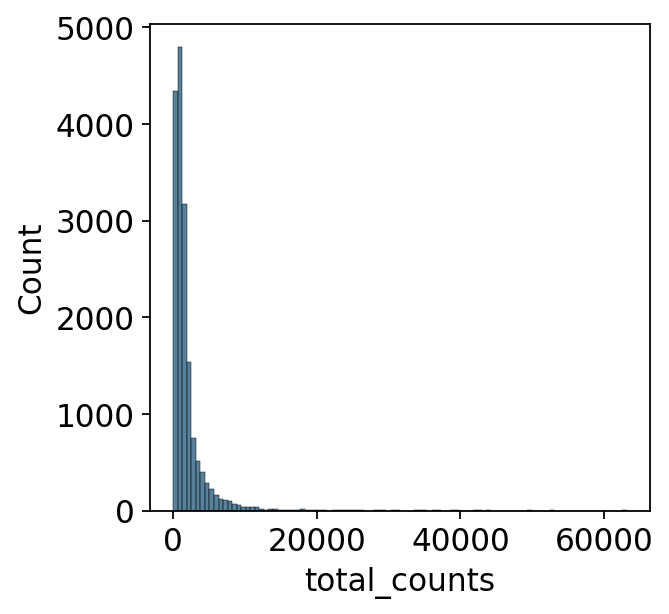

In [6]:
import seaborn as sns
# 修改说明: 若 total_counts 不存在则先计算 QC 指标，避免 KeyError
if "total_counts" not in adata.obs:
    sc.pp.calculate_qc_metrics(adata, inplace=True)
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)
# 修改说明: grid=True 用于显示网格线，便于读数
p1.grid(True)

## 2. 移位对数

我们将介绍的第一个归一化方法是基于 delta 方法的移位对数。delta 方法应用非线性函数 $f(Y)$，使得原始计数 $Y$ 中的差异更加相似。

我们定义非线性函数 $f(Y)$ 的变换如下：

$$f(y)=\log(\frac{y}{s}+y_0)$$

其中 $y$ 是原始计数，$s$ 是尺寸因子，$y_0$ 是伪计数。我们为每一个细胞确定自己的尺寸因子，以同时考虑采样效果和不同细胞尺寸的变换。细胞的尺寸因子可以计算为：

$$s_c=\frac{\sum_g y_{gc}}{L}$$

其中 $g$ 代表不同的基因，$L$ 代表基因的计数总和。确定尺寸因子的方法有很多，在 `scanpy` 中默认使用原始计数深度的中位数来计算，在 `seurat` 中使用固定值 $L=10^4$，而在 `omicverse` 的预处理中，我们将 $L$ 设定为 $50\times10^4$。不同的值会使得过度离散值 $\alpha$ 的不同。

**过度离散值 $\alpha$**

过度离散值 $\alpha$ 描述了数据集中存在着比期望更大的变异性。

移位对数是一种快速归一化技术，优于其他揭示数据集潜在结构的方法（特别是在进行主成分分析时），并且有利于方差的稳定性，以进行后续的降维和差异表达基因的识别。


#### 修改说明: 修正文件名并去掉引号，空格用 %20 编码以确保渲染
![QC plot](2026-03-10_201420.png)

移位对数是一种快速归一化技术，优于其他揭示数据集潜在结构的方法（特别是在进行主成分分析时），并且有利于方差的稳定性，以进行后续的降维和差异表达基因的识别。我们现在将检查如何将此归一化方法应用于我们的数据集。

我们可以使用pp.normalized_total来使用 scanpy 调用移位对数。

并且我们设置

target_sum=None,inplace=False

来探索两种不同的归一化技术。

In [7]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

normalizing counts per cell
    finished (0:00:00)


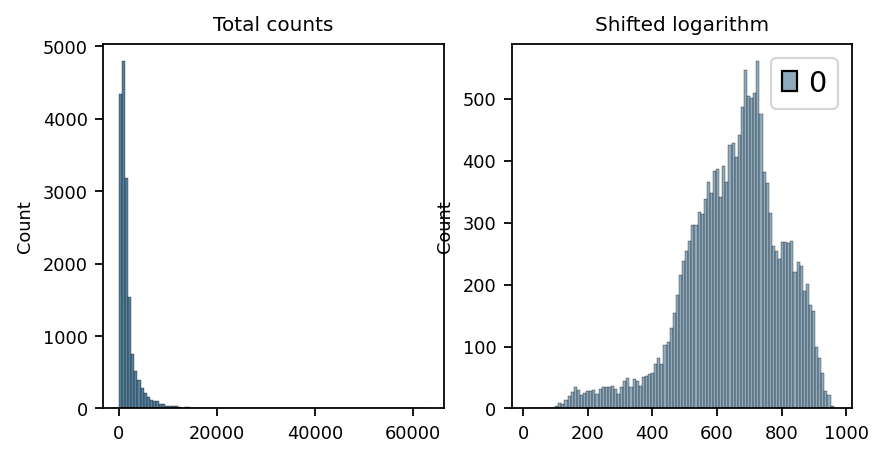

In [11]:
import matplotlib.pyplot as plt
# 修改说明: 全局调小字体，避免各类标签过大
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})
fig, axes = plt.subplots(1, 2, figsize=(6, 3)) # 6，3 plot size
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts", fontsize=9)
axes[0].set_xlabel("", fontsize=8)
axes[0].set_ylabel("Count", fontsize=8)
axes[0].tick_params(axis="both", labelsize=8)
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm", fontsize=9)
axes[1].set_xlabel("", fontsize=8)
axes[1].set_ylabel("Count", fontsize=8)
axes[1].tick_params(axis="both", labelsize=8)
plt.show()


我们发现nUMI的最大值在1000左右，经过移位对数化后，并且移位对数化后的nUMI的分布近似正态分布。